# SAE Concept Manifolds

**Goal**: After this session, you will be able to implement a TopK Sparse Autoencoder and diagnose whether it captures a continuous concept manifold *globally* (a compact basis) or *locally* (atoms that tile the manifold).

**Time**: 30 minutes.

## What and Why
Sparse Autoencoders (SAEs) are the dominant tool for mechanistic interpretability of LLMs. The standard narrative: each learned *atom* (decoder column) represents one human-interpretable concept. But many real concepts are *continuous* — days of the week, positions on a number line, dates — and live on low-dimensional manifolds inside activation space. This paper asks: does the SAE recover the manifold as a compact *global* basis (a few atoms whose span contains it), or does it *tile* the manifold locally with many narrow-region atoms? The empirical finding is "neither cleanly — the SAE dilutes between the two regimes."

## Key Formulas
Encoder (with TopK sparsity), decoder, reconstruction loss:

$$z = \mathrm{TopK}\!\left(W_{\text{enc}}\, x + b_{\text{enc}}\right) \qquad \hat{x} = W_{\text{dec}}\, z \qquad \mathcal{L} = \|x - \hat{x}\|_2^2$$

**Where:**
- $x \in \mathbb{R}^{d}$ — input activation (e.g. a residual-stream hidden state)
- $z \in \mathbb{R}^{m}$ — sparse code, $m \gg d$ (overcomplete dictionary); exactly $k$ entries are nonzero
- $W_{\text{enc}} \in \mathbb{R}^{m \times d}$, $b_{\text{enc}} \in \mathbb{R}^{m}$ — encoder
- $W_{\text{dec}} \in \mathbb{R}^{d \times m}$ — decoder (its columns are the *atoms*)
- $\mathrm{TopK}$ — keep the $k$ largest pre-activations after ReLU, zero the rest
- $\hat{x}$ — reconstruction

## Component Breakdown
- **TopK SAE forward**: linear encode -> ReLU -> top-k masking -> linear decode
- **Training**: Adam on reconstruction MSE; data sampled from a circular concept manifold embedded in 64-d
- **Manifold capture diagnostic**: per-atom angular selectivity — how restricted is each atom's active region on the circle?

## References
- Bhalla et al., "Do Sparse Autoencoders Capture Concept Manifolds?" ([arxiv:2604.28119](https://arxiv.org/abs/2604.28119), 2026)
- Gao et al., "Scaling and evaluating sparse autoencoders" (OpenAI, 2024) — TopK SAEs
- Bricken et al., "Towards Monosemanticity" (Anthropic, 2023) — foundational dictionary-learning framing


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from jaxtyping import Float
from torch import Tensor
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

# ----------------------------------------------------------------- Synthetic concept manifold
# A real example: in an LM, "day of the week" forms a 7-point cluster on a circle in residual-
# stream activation space. We simulate this with a continuous circle parameterized by angle
# theta in [0, 2*pi). Each sample's "true" 2-d coordinate is (cos(theta), sin(theta)), then
# embedded into D=64 via a fixed random orthogonal matrix + small isotropic noise. This is
# the exact same shape an LM hidden state would have: (batch, D).

D = 64                # ambient dim — matches a tiny LM's hidden size (real LMs use ~1024+)
M = 64                # SAE dictionary size (overcomplete relative to manifold rank, not D)
K = 4                 # TopK sparsity — at most 4 atoms fire per sample
N_TRAIN = 4096
NOISE_STD = 0.02

# Fixed random orthogonal embedding 2 -> D (orthogonal so the manifold geometry is preserved).
_R = torch.linalg.qr(torch.randn(D, D))[0][:, :2]  # (D, 2), columns orthonormal

def sample_manifold(n: int) -> tuple[Float[Tensor, "n D"], Float[Tensor, "n"]]:
    """Sample n points on a 2-d circle embedded in D dimensions.

    Returns:
        x:     (n, D) — embedded points + noise (same shape as LM hidden states)
        theta: (n,)   — ground-truth angle in [0, 2*pi), used only for the diagnostic
    """
    theta = torch.rand(n) * 2 * torch.pi
    coords_2d = torch.stack([theta.cos(), theta.sin()], dim=-1)  # (n, 2)
    x = coords_2d @ _R.T + NOISE_STD * torch.randn(n, D)
    return x.to(device), theta.to(device)

x_train, theta_train = sample_manifold(N_TRAIN)
print(f"x_train: {x_train.shape}  (== base_model(tokens).hidden_states[-1][:, t, :] in real use)")
print(f"theta_train: {theta_train.shape}  (ground-truth manifold coord, oracle only)")
print(f"Device: {device}")


x_train: torch.Size([4096, 64])  (== base_model(tokens).hidden_states[-1][:, t, :] in real use)
theta_train: torch.Size([4096])  (ground-truth manifold coord, oracle only)
Device: cuda


## Part 1: TopK Sparse Autoencoder
Implement the SAE forward pass. Two linear layers separated by ReLU + TopK. The TopK step is what makes the code sparse: for each sample, keep only the $k$ largest pre-activations; zero the rest.

**Predict before you code**:
- After the TopK step, how many non-zero entries does `z` have *per sample*? What is `z.sum(dim=-1).count_nonzero()` minus `z.shape[0] * k`?
- If the decoder columns are random and `z` is k-hot, what is the expected magnitude of `x_hat`?

<details><summary>Hint: TopK</summary>You want the indices of the top-k values along the last dim, then a sparse tensor that's zero everywhere except those indices. PyTorch has a built-in for the indexing half.</details>


In [2]:
class TopKSAE(nn.Module):
    """Sparse autoencoder with TopK sparsity (Gao et al. 2024).

    The TopK formulation removes the L1 penalty and instead enforces an exact
    sparsity constraint by keeping only the k largest pre-activations.
    """

    def __init__(self, d_input: int, d_hidden: int, k: int):
        super().__init__()
        self.k = k
        # Encoder
        self.W_enc = nn.Parameter(torch.randn(d_hidden, d_input) / d_input**0.5)
        self.b_enc = nn.Parameter(torch.zeros(d_hidden))
        # Decoder — columns are the "atoms". Standard SAE init: unit-norm columns.
        W_dec = torch.randn(d_input, d_hidden)
        W_dec = W_dec / W_dec.norm(dim=0, keepdim=True)
        self.W_dec = nn.Parameter(W_dec)

    def encode(self, x: Float[Tensor, "batch d_input"]) -> Float[Tensor, "batch d_hidden"]:
        pre = F.relu(x @ self.W_enc.T + self.b_enc)              # (B, M)
        topk_vals, topk_idx = pre.topk(self.k, dim=-1)           # (B, k), (B, k)
        z = torch.zeros_like(pre).scatter_(-1, topk_idx, topk_vals)
        return z

    def decode(self, z: Float[Tensor, "batch d_hidden"]) -> Float[Tensor, "batch d_input"]:
        return z @ self.W_dec.T

    def forward(
        self, x: Float[Tensor, "batch d_input"]
    ) -> tuple[Float[Tensor, "batch d_input"], Float[Tensor, "batch d_hidden"]]:
        z = self.encode(x)
        return self.decode(z), z


In [3]:
# --- Part 1 Validation ---
torch.manual_seed(42)
sae_test = TopKSAE(d_input=D, d_hidden=M, k=K).to(device)

x_batch, _ = sample_manifold(32)
x_hat, z = sae_test(x_batch)

# Shapes
assert x_hat.shape == (32, D), f"x_hat shape: expected (32, {D}), got {x_hat.shape}"
assert z.shape == (32, M), f"z shape: expected (32, {M}), got {z.shape}"
print(f"  x_hat shape: {x_hat.shape}  -- correct")
print(f"  z shape:     {z.shape}      -- correct")

# Diagnostics
print(f"  z range:     [{z.min():.4f}, {z.max():.4f}]")
print(f"  z mean nonzero per row: {(z != 0).float().sum(dim=-1).mean():.2f}  (expected exactly {K})")

# Property: exactly K nonzeros per row (this is what TopK *means*)
nonzero_per_row = (z != 0).sum(dim=-1)
assert (nonzero_per_row == K).all(), (
    f"Expected exactly {K} nonzeros per row (TopK constraint); got distribution "
    f"min={nonzero_per_row.min().item()} max={nonzero_per_row.max().item()}. "
    "Did you forget to mask the non-top-k entries to zero?"
)
print(f"  Exactly K={K} nonzeros per row -- correct")

# Property: z values must be non-negative (ReLU before TopK)
assert (z >= 0).all(), "z must be non-negative — ReLU should fire before TopK."
print(f"  z non-negative -- correct")

# Gradient flow
loss = (x_hat - x_batch).pow(2).sum()
loss.backward()
assert sae_test.W_enc.grad is not None and sae_test.W_dec.grad is not None, "No gradients on SAE weights."
print(f"  Gradients flow to W_enc and W_dec -- correct")

print("\nPart 1 complete.")


  x_hat shape: torch.Size([32, 64])  -- correct
  z shape:     torch.Size([32, 64])      -- correct
  z range:     [0.0000, 0.3845]
  z mean nonzero per row: 4.00  (expected exactly 4)
  Exactly K=4 nonzeros per row -- correct
  z non-negative -- correct
  Gradients flow to W_enc and W_dec -- correct

Part 1 complete.


## Part 2: Train the SAE
Train the TopK SAE on the circle-manifold data with Adam and MSE reconstruction loss. No sparsity penalty needed — TopK handles that.

**Predict before you code**:
- After training, what should the typical reconstruction error per coordinate look like — comparable to `NOISE_STD`, or much smaller, or much larger? Why?


In [4]:
sae = TopKSAE(d_input=D, d_hidden=M, k=K).to(device)
optimizer = torch.optim.Adam(sae.parameters(), lr=3e-3)

N_STEPS = 600
BATCH = 256
losses = []
sae.train()
for step in range(N_STEPS):
    idx = torch.randint(0, N_TRAIN, (BATCH,), device=device)
    x_batch = x_train[idx]
    x_hat, _ = sae(x_batch)
    loss = F.mse_loss(x_hat, x_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss:   {losses[-1]:.4f}")


Initial loss: 0.0202
Final loss:   0.0004


In [5]:
# --- Part 2 Validation ---
# The reconstruction floor is set by NOISE_STD: even a perfect model can't beat noise.
# Per-coord MSE floor ~ NOISE_STD**2 = 4e-4. We expect final loss within ~5x of that.
floor = NOISE_STD ** 2
print(f"  Theoretical floor (NOISE_STD**2): {floor:.5f}")
print(f"  Final loss:                       {losses[-1]:.5f}")
print(f"  Final / floor ratio:              {losses[-1] / floor:.2f}x")

assert losses[-1] < losses[0] / 4, (
    f"Loss only fell from {losses[0]:.4f} to {losses[-1]:.4f}. "
    "Training didn't converge — check lr, optimizer, or that you're computing MSE not summed SE."
)
assert losses[-1] < 5 * floor, (
    f"Final loss {losses[-1]:.4f} is more than 5x the noise floor {floor:.4f}. "
    "The SAE should comfortably reconstruct a 2-d manifold with K=4 atoms; "
    "investigate whether atoms are dead (b_enc too negative) or W_dec collapsed."
)
print(f"  Loss decreased and is near noise floor -- correct")

# Sanity: on held-out data, reconstruction should also be near floor
sae.eval()
with torch.no_grad():
    x_val, _ = sample_manifold(512)
    x_hat_val, _ = sae(x_val)
    val_mse = F.mse_loss(x_hat_val, x_val).item()
print(f"  Held-out MSE: {val_mse:.5f}  ({val_mse / floor:.2f}x floor)")
assert val_mse < 5 * floor, "SAE overfit — held-out reconstruction is worse than training."
print(f"  Held-out generalization -- correct")

print("\nPart 2 complete.")


  Theoretical floor (NOISE_STD**2): 0.00040
  Final loss:                       0.00040
  Final / floor ratio:              1.00x
  Loss decreased and is near noise floor -- correct
  Held-out MSE: 0.00040  (1.01x floor)
  Held-out generalization -- correct

Part 2 complete.


## Part 3: Manifold Capture Diagnostic — angular selectivity
The paper's central question: did the SAE capture the circle *globally* (a small basis of atoms whose linear span covers the manifold) or *locally* (many atoms, each firing in a narrow arc)?

For each atom $j$, compute its **angular selectivity** — the angular width of the arc on which it activates.

Concretely, for atom $j$:
1. Collect the angles $\{\theta_i : z_{ij} > 0\}$ — i.e. the angles where atom $j$ fired.
2. Treat these as points on the unit circle.
3. Compute the smallest arc that contains all of them (handle the wraparound at $2\pi$ correctly).

- **Selectivity ~ $2\pi$**: atom fires everywhere → contributes to a *global* basis
- **Selectivity small**: atom fires on a narrow arc → contributes to *local* tiling

**Predict before you code**:
- If the SAE had cleanly captured the manifold globally with K=4 atoms, what would the selectivity histogram look like — concentrated at one value, or spread?
- What angular range counts as "wraparound"? If $\theta = 0.01$ and $\theta = 6.27$ both fire the same atom, is that a 6.26 arc or a 0.04 arc?

<details><summary>Hint: smallest enclosing arc</summary>Sort the angles. The smallest enclosing arc on a circle equals $2\pi$ minus the largest gap between consecutive sorted angles (including the wrap-around gap from the last back to the first).</details>


In [6]:
@torch.no_grad()
def angular_selectivity(
    z: Float[Tensor, "n m"],
    theta: Float[Tensor, "n"],
) -> Float[Tensor, "m"]:
    """For each atom (column of z), return the smallest arc length (in radians)
    that contains all the angles where the atom fired. Atoms that never fire
    return float('nan').
    """
    n, m = z.shape
    selectivity = torch.full((m,), float("nan"), device=z.device)
    for j in range(m):
        firing_mask = z[:, j] > 0
        if firing_mask.sum() < 2:
            # 0 or 1 sample: define 0 (or NaN if never fires)
            if firing_mask.any():
                selectivity[j] = 0.0
            continue
        thetas_j, _ = torch.sort(theta[firing_mask])
        # gaps between consecutive sorted angles, plus the wrap-around gap
        gaps = torch.cat([thetas_j[1:] - thetas_j[:-1],
                          (thetas_j[0] + 2 * torch.pi - thetas_j[-1]).unsqueeze(0)])
        selectivity[j] = 2 * torch.pi - gaps.max()
    return selectivity


sae.eval()
with torch.no_grad():
    _, z_all = sae(x_train)            # (N, M)
selectivity = angular_selectivity(z_all, theta_train)

# Categorise
fires = ~torch.isnan(selectivity)
local = (selectivity < torch.pi / 3) & fires       # narrow arc < 60 deg
global_ = (selectivity > torch.pi) & fires         # wide arc > 180 deg
mid = fires & ~local & ~global_
dead = ~fires

print(f"Atoms total:    {M}")
print(f"  dead (never fire):   {dead.sum().item():3d}")
print(f"  local  (< pi/3):      {local.sum().item():3d}")
print(f"  middle (pi/3..pi):    {mid.sum().item():3d}")
print(f"  global (> pi):        {global_.sum().item():3d}")


Atoms total:    64
  dead (never fire):    32
  local  (< pi/3):       17
  middle (pi/3..pi):     10
  global (> pi):          5


  Shape: torch.Size([64]) -- correct
  Selectivity range: [0.0000, 3.4970] in [0, 2pi] -- correct
  Wraparound test (expect ~0.04): 0.0232
  Wraparound -- correct


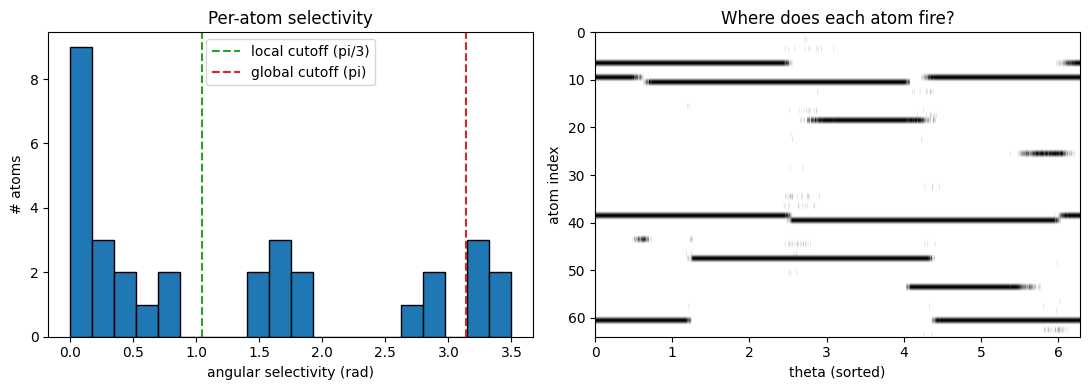


Part 3 complete.

Interpretation:
  - If you see a bimodal histogram (many local + a few global), the SAE is 'diluting'
    the manifold between the two regimes — the paper's main finding.
  - A pure global solution would show ~K=4 atoms all with selectivity ~ 2*pi.
  - A pure local solution would show all atoms with narrow selectivity.


In [7]:
# --- Part 3 Validation ---
# Sanity 1: shape
assert selectivity.shape == (M,), f"Expected shape ({M},), got {selectivity.shape}"
print(f"  Shape: {selectivity.shape} -- correct")

# Sanity 2: every selectivity in [0, 2*pi], or NaN for dead atoms
finite = selectivity[~torch.isnan(selectivity)]
assert (finite >= 0).all() and (finite <= 2 * torch.pi + 1e-5).all(), (
    f"Selectivity must lie in [0, 2*pi]; got range "
    f"[{finite.min().item():.4f}, {finite.max().item():.4f}]"
)
print(f"  Selectivity range: [{finite.min().item():.4f}, {finite.max().item():.4f}] in [0, 2pi] -- correct")

# Sanity 3: the wraparound case must be handled correctly.
# Construct an atom that fires only at theta=0.01 and theta=6.27. The enclosing arc
# should be ~0.04, NOT ~6.26.
z_synth = torch.zeros(2, 1, device=device)
z_synth[:, 0] = 1.0
theta_synth = torch.tensor([0.01, 6.27], device=device)
sel_synth = angular_selectivity(z_synth, theta_synth)
print(f"  Wraparound test (expect ~0.04): {sel_synth.item():.4f}")
assert sel_synth.item() < 0.1, (
    f"Wraparound bug: angles 0.01 and 6.27 should form a ~0.04 arc (across theta=0), "
    f"but got {sel_synth.item():.4f}. Make sure you include the gap from the last sorted "
    "angle back to the first (+2*pi)."
)
print(f"  Wraparound -- correct")

import math
# Diagnostic plot
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(finite.cpu().numpy(), bins=20, edgecolor="black")
ax[0].axvline(math.pi / 3, color="C2", linestyle="--", label="local cutoff (pi/3)")
ax[0].axvline(math.pi, color="C3", linestyle="--", label="global cutoff (pi)")
ax[0].set_xlabel("angular selectivity (rad)"); ax[0].set_ylabel("# atoms")
ax[0].set_title("Per-atom selectivity"); ax[0].legend()

# Per-atom firing as a function of theta
order = torch.argsort(theta_train)
fired = (z_all[order] > 0).float().cpu().numpy()
ax[1].imshow(fired.T, aspect="auto", cmap="gray_r",
             extent=[0, 2 * math.pi, M, 0])
ax[1].set_xlabel("theta (sorted)"); ax[1].set_ylabel("atom index")
ax[1].set_title("Where does each atom fire?")
plt.tight_layout()
plt.show()

print("\nPart 3 complete.")
print("\nInterpretation:")
print("  - If you see a bimodal histogram (many local + a few global), the SAE is 'diluting'")
print("    the manifold between the two regimes — the paper's main finding.")
print("  - A pure global solution would show ~K=4 atoms all with selectivity ~ 2*pi.")
print("  - A pure local solution would show all atoms with narrow selectivity.")


## Session Debrief

Without scrolling up, answer in your head:
1. What's the TopK sparsity rule, in one sentence?
2. Why are decoder columns ("atoms") usually initialised to *unit norm*?
3. What does it mean operationally for an SAE to capture a manifold *globally* vs *locally*?
4. If you see most atoms with selectivity > $\pi$, what kind of solution did the SAE find?

**Challenge**: Close this notebook, open a blank one, and rewrite Part 3 (the angular-selectivity diagnostic) from scratch without looking back.


## Extension (Optional)
- **Break it on purpose**: set `K=1` and re-train. What happens to the selectivity histogram, and why?
- **Change the geometry**: replace the circle with a *line segment* (set `coords_2d = torch.stack([theta, torch.zeros_like(theta)], dim=-1)` rescaled). Does the SAE switch regime?
- **Vary M**: try `M = 8` (just barely overcomplete relative to the 2-d manifold) vs `M = 256`. At which dictionary size does dilution disappear?
- **Atom inspection**: pick the atom with the smallest selectivity and the atom with the largest. Plot their $W_{\text{dec}}$ columns against the manifold's true 2-d basis (`_R[:, 0]`, `_R[:, 1]`) — what do they look like?


## Anki Cards

Add these to your deck:

**Card 1**
Front: You're reading an SAE paper and see "TopK SAE". In one sentence, what is the sparsity rule?
Back: Keep the k largest pre-activations per sample; zero the rest.

**Card 2**
Front: Decoder columns of a TopK SAE are typically initialised to what norm and why?
Back: Unit norm — so atom magnitudes are comparable.

**Card 3**
Front: Your SAE's selectivity histogram is bimodal (many narrow + a few wide). What is the SAE doing to the concept manifold?
Back: Diluting global and local capture.

**Card 4**
Front: You compute "smallest enclosing arc" on a circle and an atom firing at theta=0.01 and theta=6.27 returns ~6.26. What bug?
Back: Missing wrap-around gap.
